In [4]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [5]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [13]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [12]:
df.dropna(inplace=True)

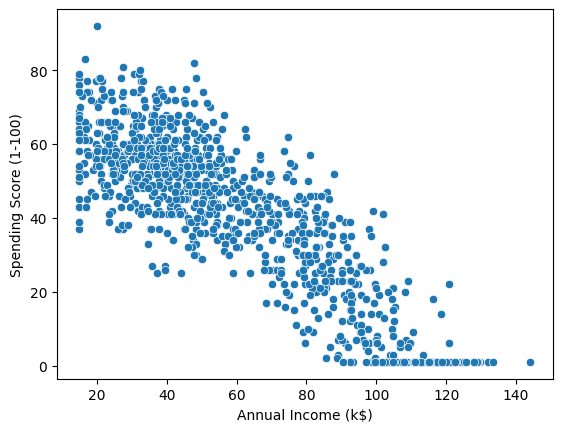

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)", data=df)
plt.show()

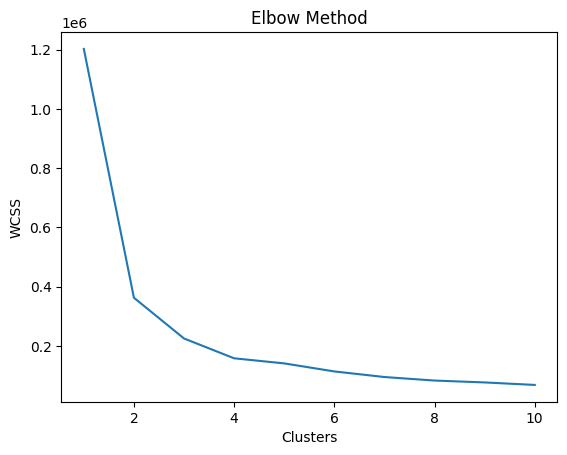

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df[["Annual Income (k$)", "Spending Score (1-100)"]])
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

df["Cluster"] = kmeans.fit_predict(df[["Annual Income (k$)", "Spending Score (1-100)"]])

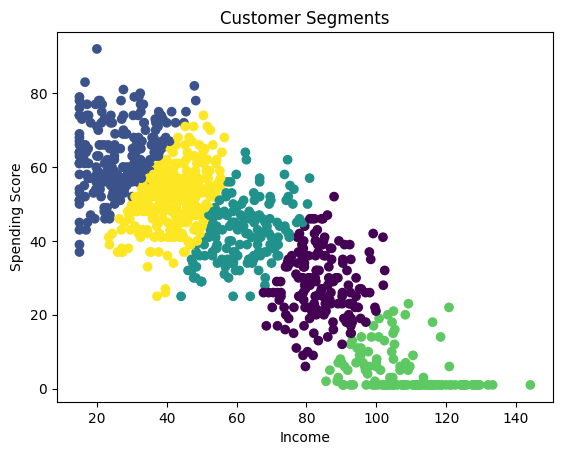

In [18]:
import matplotlib.pyplot as plt

plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=df["Cluster"])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

In [21]:
df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.359756,84.168293,28.231707
1,26.774336,26.509735,62.752212
2,38.962500,61.746250,42.218750
3,65.968750,108.168750,4.851562
4,32.648026,42.023355,51.476974
